**Breast Cancer Detection Using Machine Learning**

In [35]:
#python module downloads
!pip  install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
#importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#dataframe as df
df = pd.read_csv('data.csv')

In [38]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [39]:
# from google.colab import files
# upload = files.upload()

In [40]:
# df_1 = pd.read_csv('/content/data.csv')

In [41]:
# df_1.head()

In [42]:
# #installing the kaggle library
# ! pip install kaggle
# #make a directory named ".kaggle"
# ! mkdir ~/ .kaggle
# #copy the "kaggle.json" into this new directory
# ! cp kaggle.json ~/ .kaggle/
# #allocating the required permissions for this file
# ! chmod 600 ~/ .kaggle/kaggle.json

In [43]:
# #downloading the datasets
# ! kaggle datasets download uciml/breast-cancer-wisconsin-data

In [44]:
# #unzip the file
# ! unzip breast-cancer-wisconsin-data.zip

In [45]:
# df_1.head()

In [46]:
# EDA : Exploratory data analysis
#checking total number of rows and columns
df.shape

(569, 33)

In [47]:
#checking the data and their corresponding data types
#the properties of the data - summary of the statistics
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [48]:
#2nd way for checking null values
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [49]:
#drop the column with all missing values
# axis = 1: columns and axis = 2: rows
df = df.dropna(axis=1)

In [50]:
df.shape

(569, 32)

In [51]:
#checking datatypes
df.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [52]:
# display the count for objects, here objects are benign(B) and malignant(M)
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='diagnosis'>

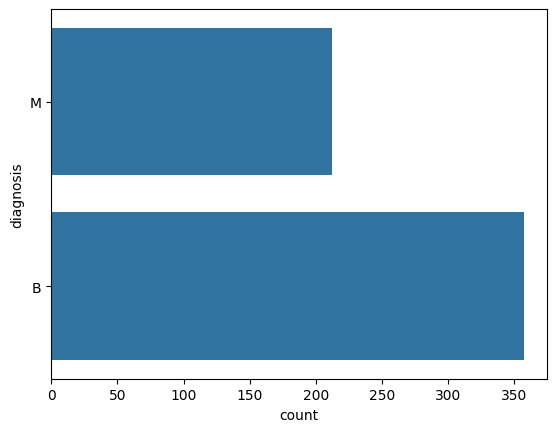

In [53]:
#visual represention of diagnosis
sns.countplot(df['diagnosis'], label = 'count')

In [54]:
#Encoding
from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()

In [55]:
from sklearn.preprocessing import LabelEncoder

labelencoder_Y = LabelEncoder()

df['diagnosis'] = labelencoder_Y.fit_transform(df['diagnosis'])

In [56]:
#printing the numerical values, M = 1, B = 0
df.iloc[:,1].values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

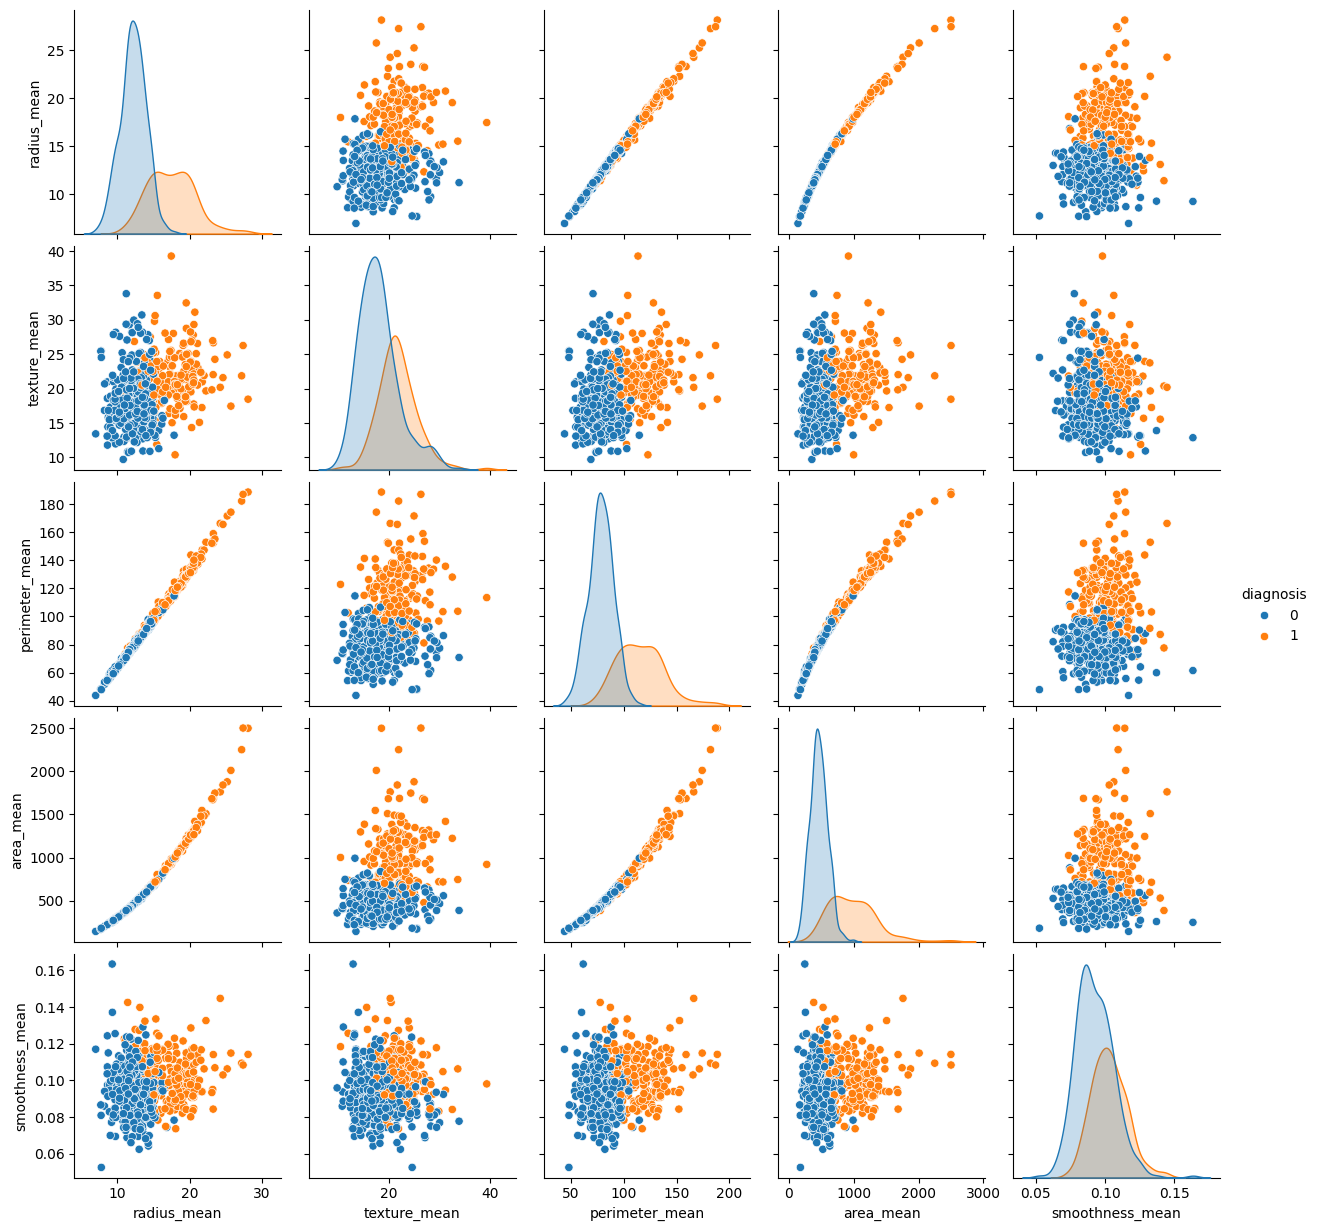

In [57]:
sns.pairplot(df.iloc[:,1:7], hue = 'diagnosis')

In [58]:
#co-relation between columns
df.iloc[:,1:11].corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000


<Axes: >

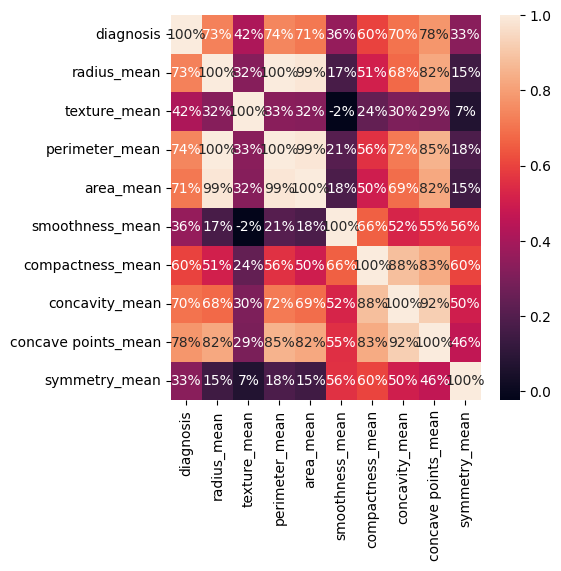

In [59]:
#heatmap
plt.figure(figsize = (5,5))
sns.heatmap(df.iloc[:,1:11].corr(), cmap ="rocket", annot = True, fmt = ".0%") # other color palletes are YlGnBu, rocket_r, tab10, etc

In [60]:
#feature scalling
#split our dataset into independent and dependent datasets
#independent --> X
#dependent --> Y
X = df.iloc[:,2:32].values
Y = df.iloc[:,1].values

In [61]:
#80:20 ratio
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.20, random_state = 0)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
print(Y_train[:5])  # First 5 elements
print(np.unique(Y_train))  # Unique values in the array
print(Y_train.dtype)  # Data type of the array
Y_train = Y_train.astype(int)  # Convert to integers


[0 0 0 0 0]
[0 1]
int64


In [64]:
X_train

array([[-1.15036482, -0.39064196, -1.12855021, ..., -0.75798367,
        -0.01614761, -0.38503402],
       [-0.93798972,  0.68051405, -0.94820146, ..., -0.60687023,
         0.09669004, -0.38615797],
       [ 0.574121  , -1.03333557,  0.51394098, ..., -0.02371948,
        -0.20050207, -0.75144254],
       ...,
       [-1.32422924, -0.20048168, -1.31754581, ..., -0.97974953,
        -0.71542314, -0.11978123],
       [-1.24380987, -0.2245526 , -1.28007609, ..., -1.75401433,
        -1.58157125, -1.00601779],
       [-0.73694129,  1.14989702, -0.71226578, ..., -0.27460457,
        -1.25895095,  0.21515662]], shape=(455, 30))

In [65]:
# Importing modules
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def models(X_train, Y_train):
    # Logistic regression classifier
    log = LogisticRegression(random_state=0)
    log.fit(X_train, Y_train)

    # Decision tree classifier
    tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
    tree.fit(X_train, Y_train)

    # Random forest classifier
    forest = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    forest.fit(X_train, Y_train)

    # Print the accuracy of each model on the training dataset
    print("The accuracy of Logistic Regression: ", log.score(X_train, Y_train))
    print("The accuracy of Decision Tree: ", tree.score(X_train, Y_train))
    print("The accuracy of Random Forest: ", forest.score(X_train, Y_train))

    return log, tree, forest



In [66]:
model = models(X_train, Y_train)

The accuracy of Logistic Regression:  0.989010989010989
The accuracy of Decision Tree:  1.0
The accuracy of Random Forest:  0.9978021978021978


In [67]:
from sklearn.metrics import confusion_matrix

# Ensure predictions are binary
predictions = (model[0].predict(X_test) > 0.5).astype(int)

# Ensure Y_test and predictions are compatible
Y_test = Y_test.astype(int)
predictions = predictions.astype(int)

# Check for shape consistency
Y_test = Y_test.ravel()
predictions = predictions.ravel()

# Compute confusion matrix
cm = confusion_matrix(Y_test, predictions)

# Extract confusion matrix components
tp = cm[0][0]
tn = cm[1][1]
fn = cm[1][0]
fp = cm[0][1]

# Print confusion matrix and accuracy
print(cm)
print("Accuracy: ", (tp + tn) / (tp + tn + fp + fn))

[[65  2]
 [ 2 45]]
Accuracy:  0.9649122807017544


In [68]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

for i in range(len(model)):
  print('Model: ',i)
  print(classification_report(Y_test, model[i].predict(X_test)))
  print(accuracy_score(Y_test, model[i].predict(X_test)))
  print()

Model:  0
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        67
           1       0.96      0.96      0.96        47

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

0.9649122807017544

Model:  1
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        67
           1       0.90      0.94      0.92        47

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114

0.9298245614035088

Model:  2
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        67
           1       0.98      0.96      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weig

In [69]:
#prediction
pred = model[2].predict(X_test)
print('Our model prediction: ')
print(pred)
print()
print('Actual prediction: ')
print(Y_test)

Our model prediction: 
[1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0
 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 1 0
 1 1 0]

Actual prediction: 
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 1
 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 1 0
 1 1 0]


Saving and Downloading the model in pkl format

In [71]:
import joblib

joblib.dump(model[2], "breast_cancer_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved successfully!")

Saved successfully!


Finding the top 10 important features while maintining the accuracy


In [ ]:
import numpy as np
import pandas as pd

# Get feature importance scores
feature_importance = model[2].feature_importances_  # Accessing RandomForest model

# Use actual feature names from the dataset (excluding target column)
df = pd.read_csv('/content/data.csv')  # Load the dataset again if needed
feature_names = df.columns[2:31]  # Selecting actual feature names

# Ensure lengths match
if len(feature_names) != len(feature_importance):
    print(f"Mismatch: {len(feature_names)} feature names vs {len(feature_importance)} importance scores")

# Create DataFrame for visualization
feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importance})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display top features
print(feature_importance_df.head(10))  # Show top 10 most important features


                 Feature  Importance
7    concave points_mean    0.221213
23            area_worst    0.181682
2         perimeter_mean    0.106572
20          radius_worst    0.086698
6         concavity_mean    0.067109
27  concave points_worst    0.049185
26       concavity_worst    0.040921
21         texture_worst    0.031495
13               area_se    0.027068
22       perimeter_worst    0.022817
